# Vergleichende Analyse des Token-Längen-Experiments (Metrik: 256 vs. 500 vs. 1000 Tokens)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und visualisiert den Einfluss unterschiedlicher maximaler Token-Sequenzlängen (**256**, **500**, **1000**) auf die **Simplicity-Metrik-Modelle (BiLSTM MixUp Regressoren)**:
1. **Statistische Evaluation auf dem Lebenshilfe-Datensatz:** Vorhersagewerte auf Leichter Sprache (LS) vs. Alltagssprache (AS), Trennschärfe (Separation Margin) und Klassifikationsgenauigkeit.
2. **Längen-Bias & Längenstabilität:** Korrelation zwischen Textlänge und Vorhersagewert sowie stratifizierte Analyse nach Textlängen-Klassen.
3. **KDE-Dichteverteilungs-Plots:** Darstellung der Verteilungen (Grün für LS, Blau für AS) im Format der Referenzabbildung.

---

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.titlesize"] = 14

METRIC_SUMMARY_CSV = "../../../results/evaluation/token_length_metric_comparison.csv"
METRIC_DETAILS_CSV = "../../../results/evaluation/token_length_metric_details.csv"

# Fallback paths if executed from project root
if not os.path.exists(METRIC_SUMMARY_CSV):
    METRIC_SUMMARY_CSV = "results/evaluation/token_length_metric_comparison.csv"
    METRIC_DETAILS_CSV = "results/evaluation/token_length_metric_details.csv"

## 1. Statistische Auswertung auf dem Lebenshilfe-Datensatz

In [2]:
if os.path.exists(METRIC_DETAILS_CSV):
    df_details = pd.read_csv(METRIC_DETAILS_CSV)
    
    records = []
    for model_name, label in [
        ('metric_mixup_256', 'BiLSTM MixUp (256 Tokens)'),
        ('metric_mixup_500', 'BiLSTM MixUp (500 Tokens)'),
        ('metric_mixup_1000', 'BiLSTM MixUp (1000 Tokens)')
    ]:
        sub = df_details[df_details['metric_model'] == model_name]
        ls_p = sub['score_ls'].values
        as_p = sub['score_as'].values
        
        mean_ls = np.mean(ls_p)
        std_ls = np.std(ls_p)
        mean_as = np.mean(as_p)
        std_as = np.std(as_p)
        
        correct_ls = np.sum(ls_p > 0.5)
        correct_as = np.sum(as_p <= 0.5)
        total = len(ls_p) + len(as_p)
        
        acc = (correct_ls + correct_as) / total
        bacc = ((correct_ls / len(ls_p)) + (correct_as / len(as_p))) / 2.0
        mae = (np.sum(1.0 - ls_p) + np.sum(as_p)) / total
        
        records.append({
            'Modell': label,
            'Ø Lambda (LS)': f'{mean_ls:.4f} ± {std_ls:.3f}',
            'Ø Lambda (AS)': f'{mean_as:.4f} ± {std_as:.3f}',
            'Separation (LS - AS)': f'{(mean_ls - mean_as):.4f}',
            'Accuracy (Schwelle 0.5)': f'{acc * 100:.2f}%',
            'Balanced Acc': f'{bacc * 100:.2f}%',
            'MAE (Target 1/0)': f'{mae:.4f}'
        })
    
    df_lh_summary = pd.DataFrame(records)
    print("\n=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
    display(df_lh_summary)
else:
    print(f"Datei {METRIC_DETAILS_CSV} nicht gefunden.")


=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================


,Modell,Ø Lambda (LS),Ø Lambda (AS),Separation (LS - AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,BiLSTM MixUp (256 Tokens),0.7744 ± 0.104,0.1136 ± 0.073,0.6608,97.30%,97.30%,0.1696
1,BiLSTM MixUp (500 Tokens),0.7557 ± 0.128,0.1363 ± 0.088,0.6194,98.65%,98.65%,0.1903
2,BiLSTM MixUp (1000 Tokens),0.7788 ± 0.128,0.1160 ± 0.100,0.6628,98.65%,98.65%,0.1686


## 2. Kernmetriken im Vergleich (LS- vs. AS-Scores und Separation Margin)

/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_50446/657188729.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_m, x='max_seq_len', y='separation_margin', ax=axes[1], palette='Blues_d')


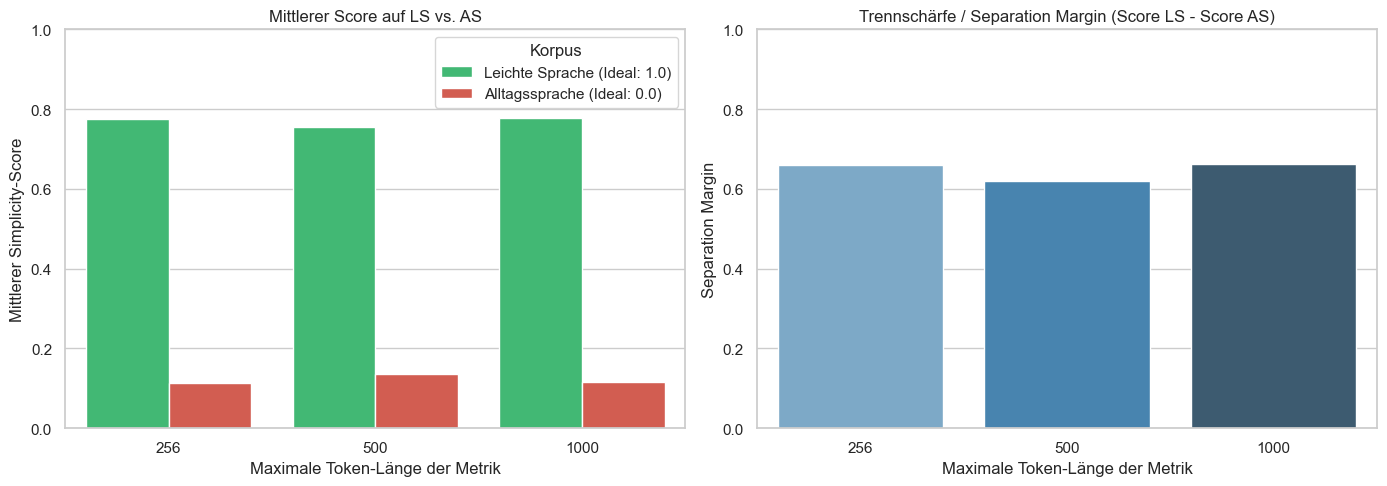

In [3]:
if os.path.exists(METRIC_SUMMARY_CSV):
    df_m = pd.read_csv(METRIC_SUMMARY_CSV)
    df_m = df_m[df_m['metric_model'] != 'metric_mixup_master']  # 256, 500, 1000
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Scores auf LS vs AS
    df_melt = pd.melt(df_m, id_vars=['metric_model', 'max_seq_len'], value_vars=['mean_score_ls', 'mean_score_as'], 
                      var_name='Korpus', value_name='Score')
    df_melt['Korpus'] = df_melt['Korpus'].replace({'mean_score_ls': 'Leichte Sprache (Ideal: 1.0)', 'mean_score_as': 'Alltagssprache (Ideal: 0.0)'})
    
    sns.barplot(data=df_melt, x='max_seq_len', y='Score', hue='Korpus', ax=axes[0], palette=['#2ECC71', '#E74C3C'])
    axes[0].set_title("Mittlerer Score auf LS vs. AS")
    axes[0].set_xlabel("Maximale Token-Länge der Metrik")
    axes[0].set_ylabel("Mittlerer Simplicity-Score")
    axes[0].set_ylim(0, 1.0)
    
    # 2. Separation Margin
    sns.barplot(data=df_m, x='max_seq_len', y='separation_margin', ax=axes[1], palette='Blues_d')
    axes[1].set_title("Trennschärfe / Separation Margin (Score LS - Score AS)")
    axes[1].set_xlabel("Maximale Token-Länge der Metrik")
    axes[1].set_ylabel("Separation Margin")
    axes[1].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

## 3. Stratifizierte Trennschärfe nach Textlänge der Artikel
Untersuchung, wie gut die Modelle auf kurzen (< 200 Tokens), mittleren (200-450 Tokens) und langen (> 450 Tokens) Artikeln trennen.

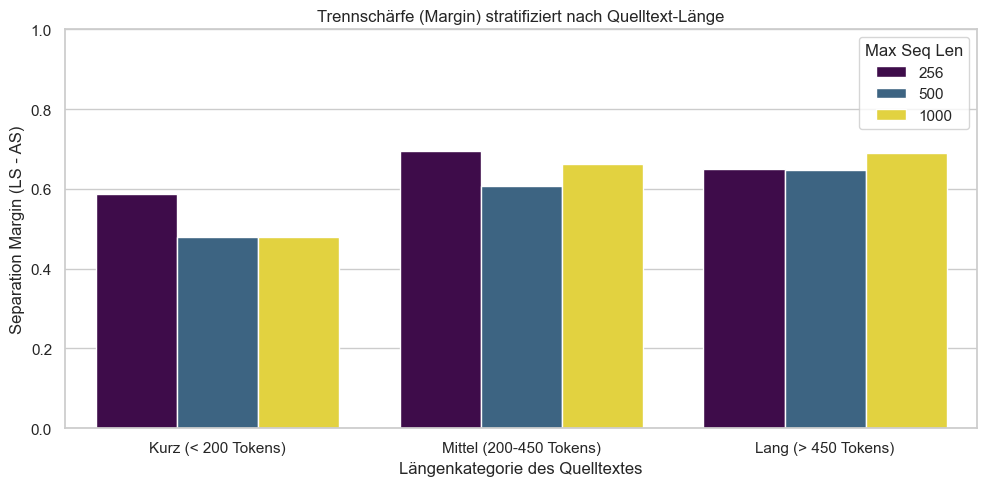

In [4]:
if os.path.exists(METRIC_SUMMARY_CSV):
    df_m = pd.read_csv(METRIC_SUMMARY_CSV)
    df_m = df_m[df_m['metric_model'] != 'metric_mixup_master']
    
    df_strat = pd.melt(df_m, id_vars=['max_seq_len'], value_vars=['margin_short', 'margin_med', 'margin_long'],
                       var_name='Längenklasse', value_name='Separation Margin')
    df_strat['Längenklasse'] = df_strat['Längenklasse'].replace({
        'margin_short': 'Kurz (< 200 Tokens)',
        'margin_med': 'Mittel (200-450 Tokens)',
        'margin_long': 'Lang (> 450 Tokens)'
    })
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_strat, x='Längenklasse', y='Separation Margin', hue='max_seq_len', palette='viridis')
    plt.title("Trennschärfe (Margin) stratifiziert nach Quelltext-Länge")
    plt.xlabel("Längenkategorie des Quelltextes")
    plt.ylabel("Separation Margin (LS - AS)")
    plt.ylim(0, 1.0)
    plt.legend(title="Max Seq Len")
    plt.tight_layout()
    plt.show()

## 4. KDE-Plots der Dichteverteilungen (256 vs. 500 vs. 1000 Tokens)
Visuelle Gegenüberstellung der drei Token-Längen:
- **Grüne Fläche:** `LS (Leichte Sprache)`
- **Blaue Fläche:** `AS (Alltagssprache)`
- **X-Achse:** `Lambda (Anteil LS)`
- **Y-Achse:** `Dichte`

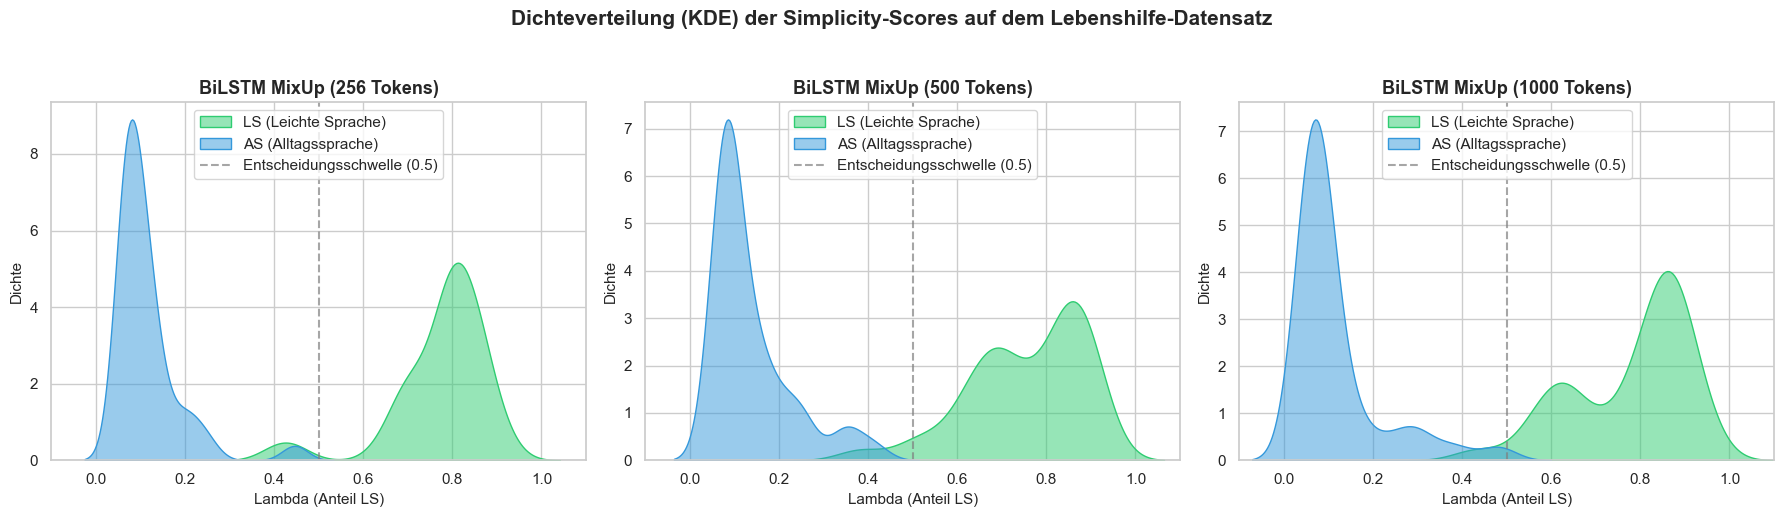

In [5]:
if os.path.exists(METRIC_DETAILS_CSV):
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    model_configs = [
        ('metric_mixup_256', 'BiLSTM MixUp (256 Tokens)'),
        ('metric_mixup_500', 'BiLSTM MixUp (500 Tokens)'),
        ('metric_mixup_1000', 'BiLSTM MixUp (1000 Tokens)')
    ]

    for i, (model_name, title) in enumerate(model_configs):
        ax = axes[i]
        sub = df_details[df_details['metric_model'] == model_name]
        
        sns.kdeplot(sub['score_ls'], fill=True, color='#2ECC71', label='LS (Leichte Sprache)', alpha=0.5, bw_adjust=0.8, ax=ax)
        sns.kdeplot(sub['score_as'], fill=True, color='#3498DB', label='AS (Alltagssprache)', alpha=0.5, bw_adjust=0.8, ax=ax)
        
        ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Entscheidungsschwelle (0.5)')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Lambda (Anteil LS)', fontsize=11)
        ax.set_ylabel('Dichte', fontsize=11)
        ax.set_xlim(-0.1, 1.1)
        ax.legend(loc='upper center', frameon=True)

    plt.suptitle('Dichteverteilung (KDE) der Simplicity-Scores auf dem Lebenshilfe-Datensatz', fontsize=15, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()